# RNN

## First Example

In [1]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
x = np.linspace(0,50,501)
y = np.sin(x)

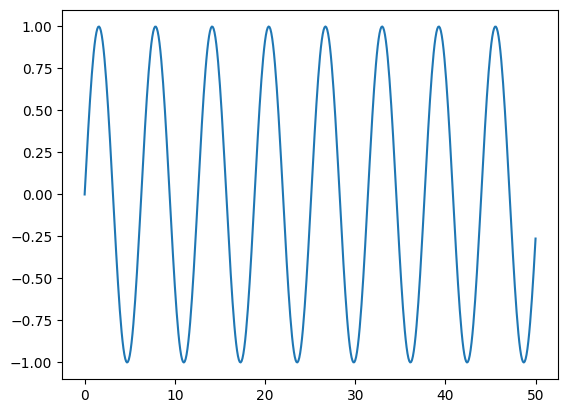

In [3]:
plt.plot(x,y)

In [4]:
df = pd.DataFrame(data=y,index=x,columns=['Sine'])

In [5]:
test_percent = 0.1

In [6]:
len(df)*test_percent

50.1

In [9]:
test_point = np.round(len(df)*test_percent)

In [10]:
test_ind = int(len(df)-test_point)

In [11]:
train = df.iloc[:test_ind]

In [12]:
test = df.iloc[test_ind:]

### Scale

In [18]:
from sklearn.preprocessing import MinMaxScaler

In [19]:
scaler = MinMaxScaler()

In [20]:
scaler.fit(train)

MinMaxScaler()

In [21]:
scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)

### SeriesGenerator 

In [22]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [37]:
length = 10  # Length of the output sequences, it must stored the patron
batch_size = 1 # Number of timeseries samples in each batch
# Para generar que el array xn sea mayor, se usa target [x1,..,,xn-1] [xn] 

generator = TimeseriesGenerator(scaled_train, scaled_train, length = length,batch_size = batch_size)

In [39]:
scaled_train[0:11]

array([[0.49999912],
       [0.54991622],
       [0.59933458],
       [0.64776041],
       [0.69470985],
       [0.73971381],
       [0.78232262],
       [0.82211054],
       [0.85868004],
       [0.89166571],
       [0.92073798]])

In [40]:
generator[0]

(array([[[0.49999912],
         [0.54991622],
         [0.59933458],
         [0.64776041],
         [0.69470985],
         [0.73971381],
         [0.78232262],
         [0.82211054],
         [0.85868004],
         [0.89166571]]]),
 array([[0.92073798]]))

<Axes: >

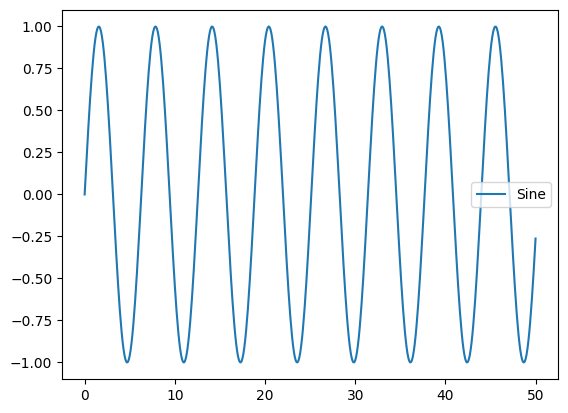

In [41]:
df.plot()

### Creating the model

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM,SimpleRNN, Input

In [43]:
n_features = 1 # try to predict y

In [59]:
# define model
model = Sequential()

# Simple RNN layer
model.add(Input(shape=(10, 1)))
model.add(SimpleRNN(12))

# Final Prediction
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

In [60]:
model.fit(generator,epochs=20)

Epoch 1/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1752
Epoch 2/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0015
Epoch 3/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.9865e-04
Epoch 4/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 2.8423e-04
Epoch 5/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 2.2389e-04
Epoch 6/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1.7019e-04
Epoch 7/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.4780e-04
Epoch 8/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 9.1490e-05
Epoch 9/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 8.2099e-05
Epoch 10/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 5.6320e-05
Epoch 11/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 7.1478e-05
Epoch 12/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5.4574e-05
Epoch 13/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6.0053e-05
Epoch 14/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 7.0637e-05
Epoch 1

In [64]:
losses = pd.DataFrame

In [65]:
model.history.history.keys()

dict_keys(['loss'])

<Axes: >

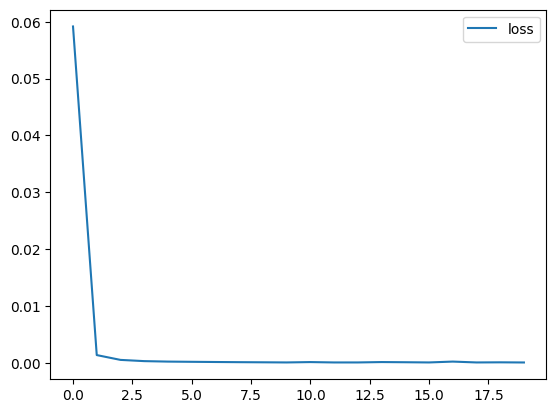

In [66]:
losses = pd.DataFrame(model.history.history)
losses.plot()

In [84]:
first_eval_batch = scaled_train[-length:] #Muestra test

In [85]:
first_eval_batch = first_eval_batch.reshape((1,length,n_features))

In [87]:
model.predict(first_eval_batch)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


array([0.94352084], dtype=float32)

In [70]:
scaled_test[0]

array([0.94955134])

In [72]:
test_predictions = []

first_eval_batch = scaled_train[-length:]
current_batch = first_eval_batch.reshape((1,length,n_features))


In [77]:
first_eval_batch

array([[0.55871522],
       [0.60799362],
       [0.65619297],
       [0.70283168],
       [0.74744376],
       [0.78958345],
       [0.82882972],
       [0.86479041],
       [0.89710623],
       [0.92545429]])

In [73]:
current_batch # []

array([[[0.55871522],
        [0.60799362],
        [0.65619297],
        [0.70283168],
        [0.74744376],
        [0.78958345],
        [0.82882972],
        [0.86479041],
        [0.89710623],
        [0.92545429]]])

In [76]:
predicted_value = [[99]]
np.append(current_batch[:,1:,:],[predicted_value], axis = 1)

array([[[ 0.60799362],
        [ 0.65619297],
        [ 0.70283168],
        [ 0.74744376],
        [ 0.78958345],
        [ 0.82882972],
        [ 0.86479041],
        [ 0.89710623],
        [ 0.92545429],
        [99.        ]]])

In [88]:
# Test Predictions
test_predictions = []

first_eval_batch = scaled_train[-length:]
current_batch = first_eval_batch.reshape((1,length,n_features))

for i in range(len(test)):
    current_pred = model.predict(current_batch)

    test_predictions.append(current_pred)

    current_batch = np.append(current_batch[:,1:,:],[current_pred], axis = 1)
    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━

In [119]:
values = np.array([[arr[0, 0]] for arr in test_predictions])
true_predictions = scaler.inverse_transform(values)

In [120]:
test['Predictions'] = true_predictions

C:\Users\Pedro Delgado Jiméne\AppData\Local\Temp\ipykernel_13756\4269337381.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = true_predictions


<Axes: >

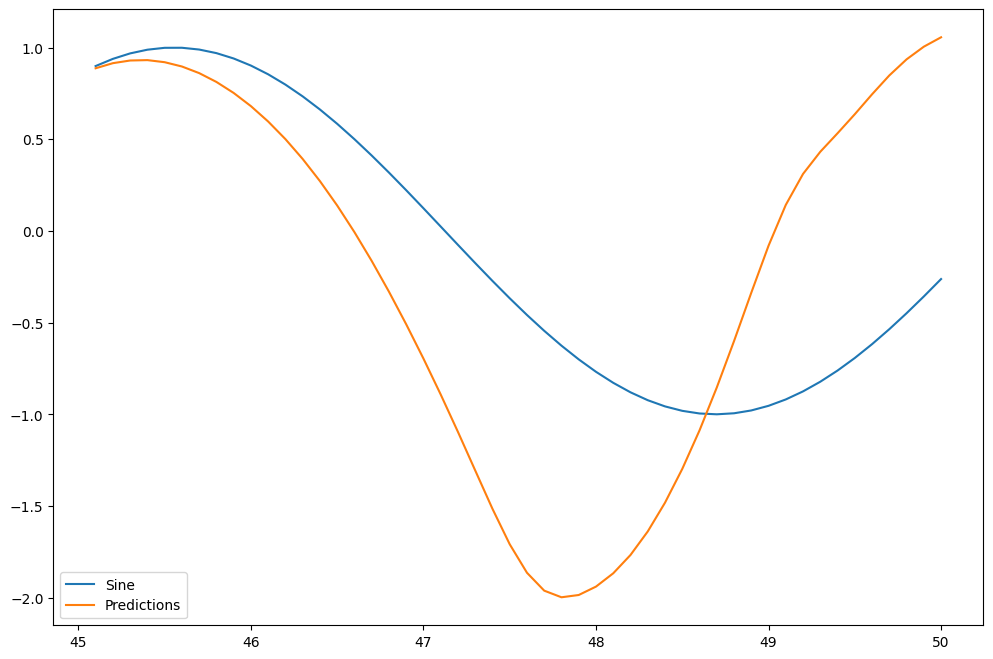

In [123]:
test.plot(figsize = (12,8))